In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')
import arviz as az
import pymc as pm
#from main_pool import Main
#from calibr_funcs import plot_results
import calibr_funcs
from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel
import scipy.stats as stats
from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data
from source.autoencoder import AESurrogateModel
#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
'''
%load_ext autoreload
%autoreload 2
'''
pm.__version__  

'5.25.1'

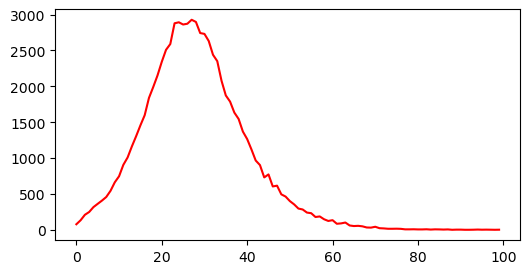

In [2]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.1
true_alpha = 0.95

init_inf = 1e-4
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
plt.subplots(figsize=(6,3))

observed_data = pd.read_csv('incidence_synthetic_curve.csv'
                           ).iloc[:100]
observed_data.columns=['incidence']

beta_arr = np.arange(0.1, 1, 0.01) #np.arange(0.04, 0.09, 0.01)
alpha_arr = np.arange(0.2, 1, 0.01) #np.arange(0.005, 0.011, 0.001)

plt.plot(observed_data,color='red')


0.15128829480425082 0.8855652941232486
[0]


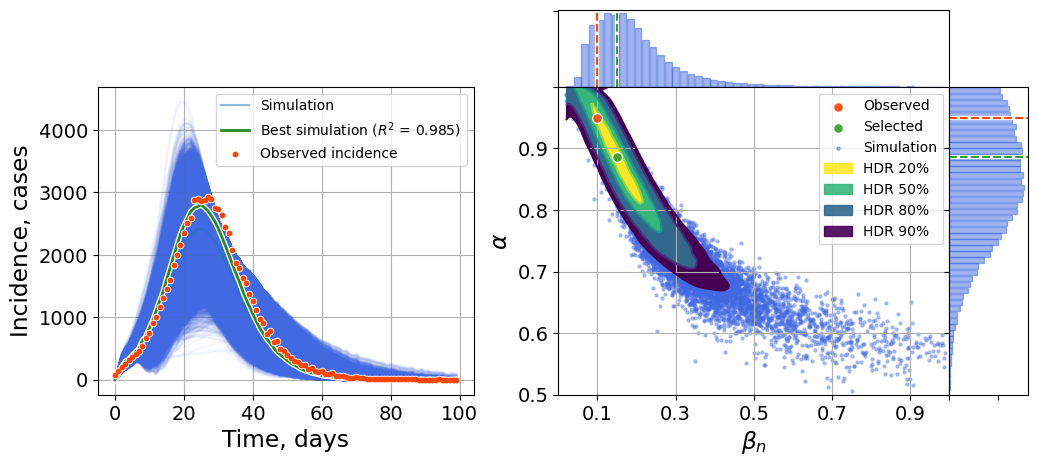

In [4]:
with_switch=np.array(False) 
with_df=[False]
num_runs=[0]
frac=[1]
gamma = 0.3
delta=0.2
n_nodes=100000

network_params=[with_switch,num_runs,frac,gamma,delta,n_nodes]

idata = az.from_netcdf(f"ba_surr.nc")

plot_funcs.plot_calib(observed_data, idata, 
               true_tau, true_alpha, 
               network_params)


In [3]:
df_c = pd.read_excel('../network_hybrid_33/sum_intensity/data1990_2019.xlsx')
df_c = df_c[(df_c.cld_year >= 2009)&(df_c.cld_year < 2020)]

# qty_total - qty_15
# remove people older than 15, because children's data has less underreporting
df_c['qty_lt15'] = df_c['qty_total'] - df_c['qty_15']
df_c['wd_lt15'] = df_c['wd_total'] - df_c['wd_15']

# we combine [40w:52w] year x  AND  [0w:20w] year x+1
df_c = df_c[~((df_c.cld_year == 2009)&(df_c.week_number < 40))]
df_c = df_c[~((df_c.cld_year == 2019)&(df_c.week_number > 40))]
df_c = df_c[((df_c.week_number >= 40)|(df_c.week_number <= 39))]
df_c = df_c[['town_name','cld_year','week_number','qty_lt15','wd_lt15','qty_total','qty_15','wd_total','wd_15']]
df_c['years_part'] = ''
ntowns = df_c.town_name.nunique()
df_c = df_c[df_c.week_number!=53]
nweeks =  df_c.week_number.nunique()

for i in np.arange(2009,2019):
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'years_part'] = f'{i}{i+1}'
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=39)),
             'yp_week'] = [*np.arange(1,nweeks+1)]*ntowns
    
df_c.head()

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part,yp_week
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010,1.0
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010,2.0
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010,3.0
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010,4.0
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010,5.0


<Axes: xlabel='yp_week', ylabel='wd_total'>

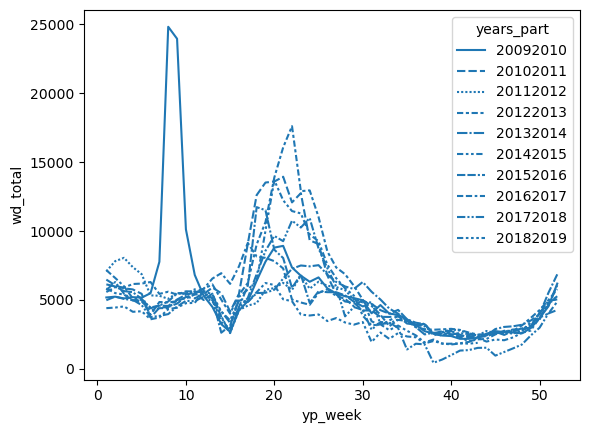

In [4]:
sns.lineplot(x = df_c[df_c.town_name=='Самара'].yp_week,
            y = df_c[df_c.town_name=='Самара'].wd_total, 
             style=df_c[df_c.town_name=='Самара'].years_part)

In [2]:
import surr_on_real.epid_data as epd

In [3]:
pcr = pd.read_csv('surr_on_real/ПЦР_Самара_Челябинск_Волгоград_Спб_18_11_2024.csv', 
            sep=';', header=1).iloc[1:,:7]
pcr_table_from_excel_to_python = {
    "date": "Дата",
    "tested_total": "Число образцов тестированных на грипп",
    "tested_strain_0": "A (субтип не определен)",
    "tested_strain_1": "A(H1)pdm09",
    "tested_strain_2": "A(H3)",
    "tested_strain_3": "B",
}
pcr.head(2)

,Unnamed: 0,Unnamed: 1,Число образцов тестированных на грипп,A (субтип не определен),A(H1)pdm09,A(H3),B
1,2010.1 (04.01.2010 - 10.01.2010),Н,0,0,0,0,0
2,2010.2 (11.01.2010 - 17.01.2010),Н,46,0,3,0,0


In [8]:
epid = epd.EpidData(city = '', 
             path='surr_on_real/',
            start_time='04-01-2019',
            end_time='04-12-2019')

In [14]:
epid.cases_df.columns

Index(['date', 'sars_total_cases', 'sars_cases_age_group_0',
       'sars_cases_age_group_1', 'sars_cases_age_group_2',
       'sars_cases_age_group_3', 'total_population', 'population_age_group_0',
       'population_age_group_1', 'population_age_group_2',
       'population_age_group_3', 'datetime', 'rel_strain_0',
       'real_cases_strain_0', 'rel_strain_1', 'real_cases_strain_1',
       'rel_strain_2', 'real_cases_strain_2', 'rel_strain_3',
       'real_cases_strain_3'],
      dtype='object')

In [19]:
epid.cases_df.loc[:, ['date', 'sars_total_cases','total_population', 
 'datetime', 'rel_strain_0',
       'real_cases_strain_0', 'rel_strain_1', 'real_cases_strain_1',
       'rel_strain_2', 'real_cases_strain_2', 'rel_strain_3',
       'real_cases_strain_3']]

,date,sars_total_cases,total_population,datetime,rel_strain_0,real_cases_strain_0,rel_strain_1,real_cases_strain_1,rel_strain_2,real_cases_strain_2,rel_strain_3,real_cases_strain_3
0,2010.1 (04.01.2010 - 10.01.2010),2692,1161112,2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010.2 (11.01.2010 - 17.01.2010),4240,1161112,2010-01-11,0.0,0.0,0.065217,277.0,0.0,0.0,0.0,0.0
2,2010.3 (18.01.2010 - 24.01.2010),4915,1161112,2010-01-18,0.0,0.0,0.052632,259.0,0.0,0.0,0.0,0.0
3,2010.4 (25.01.2010 - 31.01.2010),6392,1161112,2010-01-25,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,2010.5 (01.02.2010 - 07.02.2010),7780,1161112,2010-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
769,2024.40 (30.09.2024 - 06.10.2024),6655,1163724,2024-09-30,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
770,2024.41 (07.10.2024 - 13.10.2024),8584,1163724,2024-10-07,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
771,2024.42 (14.10.2024 - 20.10.2024),6430,1163724,2024-10-14,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
772,2024.43 (21.10.2024 - 27.10.2024),6611,1163724,2024-10-21,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [21]:
0.065217 * 4240

276.52008

In [6]:


city = 'russia'
save_path_folder='./dinara/report_rscf/'
epid_data = InfluenzaData(city, begin_year=2025, begin_week=40, end_year=2025, end_week=49)

NameError: name 'InfluenzaData' is not defined

In [5]:
epid_data

NameError: name 'epid_data' is not defined

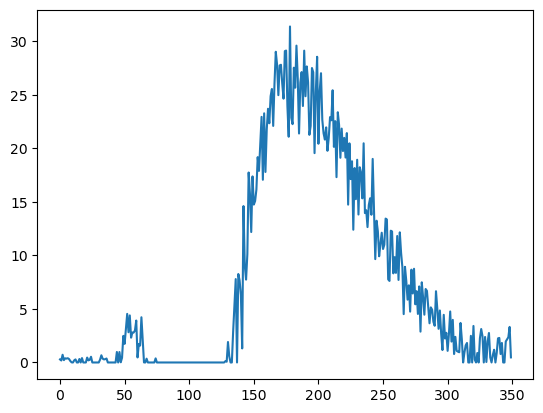

In [170]:
model = AESurrogateModel(10**5, 'sw')
q = model.simulate(0.005,0.87)
q[q<0] = 0
plt.plot(q)

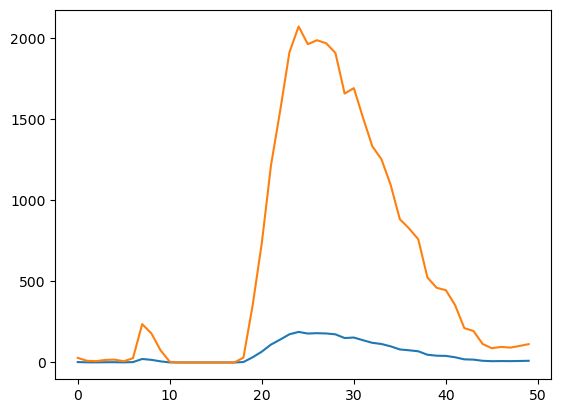

In [171]:
kk = pd.Series(q).groupby(pd.Series(q).index // 7).sum() 
plt.plot(kk)
plt.plot(kk*11)

In [75]:
pd.Series(q).groupby(pd.Series(q).index // 7).sum().values.shape

(50,)

In [ ]:
week_data

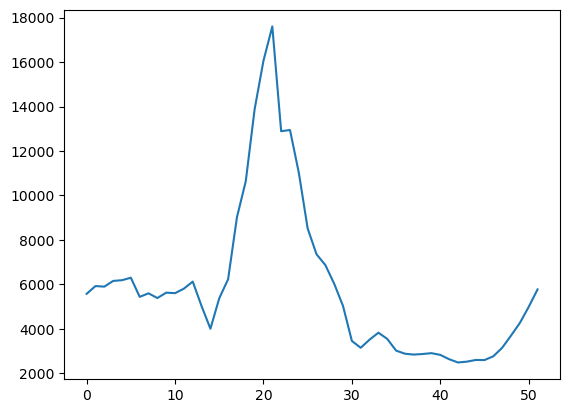

In [7]:
town = 'Самара'
year = 2012
data = df_c[(df_c.town_name==town)&(df_c.years_part==f'{year}{year+1}')]
pop = data.qty_total.mean()
incidence = data.wd_total.values

plt.plot(incidence)

In [8]:
incidence.shape

(52,)

In [89]:
int(pop/ n_nodes)

11

In [93]:
[1,2,3]*2

[1, 2, 3, 1, 2, 3]

In [192]:
def surr_sim(rng, alpha, beta, modeling_duration, 
             pop, n_nodes, top, koeff,
            size=None):
    modeling_duration = modeling_duration[0]
    pop = pop[0]
    n_nodes =n_nodes[0]
    top =top[0]
    koeff = koeff[0]
    
    if top:
        top_str = 'ba'
    else:
        top_str = 'sw'
    model = AESurrogateModel(10**5, top_str)
    #alpha, beta
    q = model.simulate(alpha,beta)
    
    q[q<0] = 0
    week_data = pd.Series(q).groupby(pd.Series(q).index // 7).sum().values
    
    diff_w = week_data.shape[0] - modeling_duration
    # если меньше -- добавляем нули
    if diff_w < 0:
        week_data = [*week_data,*[0]*abs(diff_w)]
    else:
        week_data = week_data[abs(diff_w):]#week_data[:modeling_duration]
        
    return ([i*koeff for i in week_data])

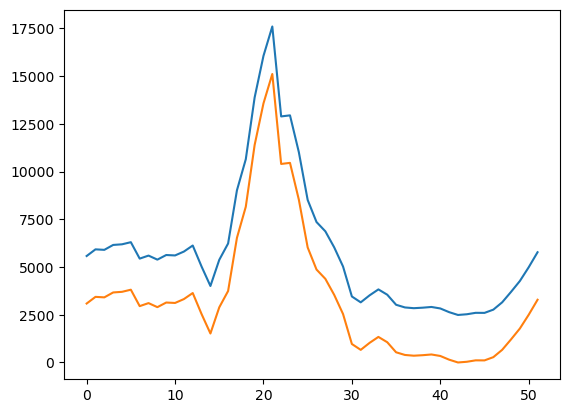

In [193]:
plt.plot(new_observed)
plt.plot(new_observed - new_observed.min())

In [207]:
# 851.69
draws = 200
chains = 4
progressbar = True


epsilon=500
gamma = [0.3]
delta=[0.2]
n_nodes=[100000]
top = [False] #is BA?
koeff = [int(pop/ n_nodes)]
modeling_duration = [incidence.shape[0]]

new_observed = incidence - incidence.min()

with pm.Model() as pm_modelp:
    real_data = pm.Data("incidence", new_observed)
    alpha = pm.Uniform(name="alpha", lower=10/n_nodes[0], upper=1.)
    beta = pm.Uniform(name="tau", lower=0., upper=1.)
    
    # вынесем, тк для прогноза нужно будет задавать размер
    
    sim = pm.Simulator("sim", surr_sim, 
                        params = (alpha, beta, 
                                  modeling_duration, 
                                  [pop], n_nodes, top, koeff
                                 ),   
                       
                        epsilon=epsilon, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=new_observed
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idatap = pm.sample_smc(#tune=tune, 
                          draws=draws, 
        chains=chains,
                          #step=step, 
        return_inferencedata=True,
                          progressbar=progressbar)
    end_time = time.time()
    idatap.extend(pm.sample_posterior_predictive(idatap, 
                                                 progressbar=progressbar))

# It took  32616.331862449646 sec
print('It took ', end_time-start_time, 'sec')


idata = idatap.copy()

idata.sample_stats = idata.sample_stats.drop('beta')
idata.sample_stats = idata.sample_stats.drop('log_marginal_likelihood')
idata.sample_stats = idata.sample_stats.drop('accept_rate')
idata.to_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")


Initializing SMC sampler...
Sampling 4 chains in 4 jobs


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


It took  23.694233655929565 sec


'surr_on_real/sw_surr_200_4_eps500_g0.3_d0.2.nc'

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 483, in superreload
    module = reload(module)
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]



0.9995426548697661 0.2717054448501091
[0]


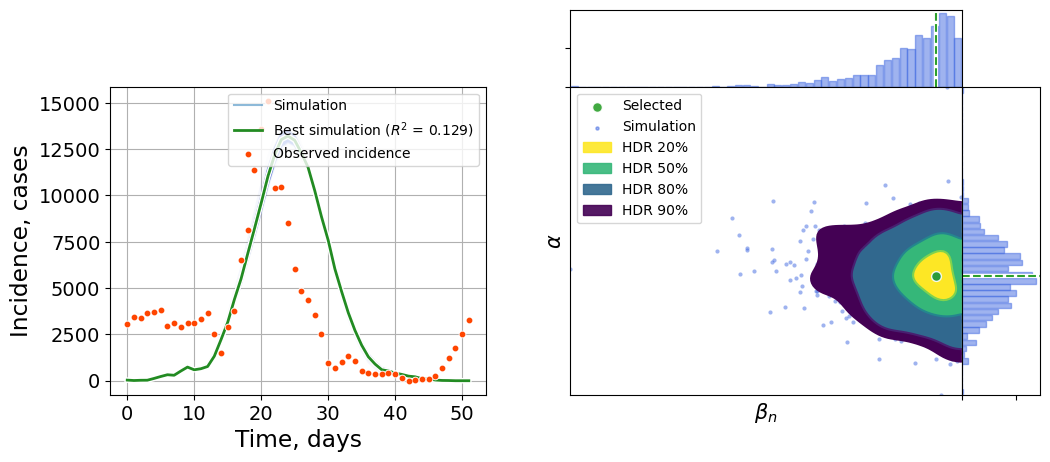

In [208]:
idatat = az.from_netcdf(f"surr_on_real/sw_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(new_observed), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)

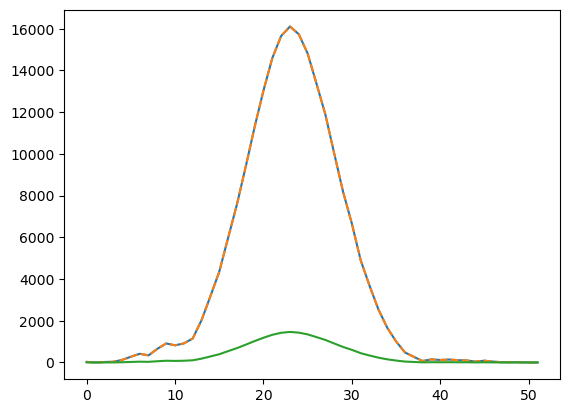

In [198]:
model = AESurrogateModel(10**5, 'sw')

p0, p1 = 0.997967156275798, 0.28623118170178513
q = model.simulate(p1,p0)#[:data.shape[0]]
q[q<0] = 0

week_data = pd.Series(q).groupby(pd.Series(q).index // 7).sum().values 
diff_w = week_data.shape[0] - modeling_duration[0]
# если меньше -- добавляем нули
if diff_w < 0:
    week_data = [*week_data,*[0]*abs(diff_w)]
else:
    week_data = week_data[:modeling_duration]
q = [i*koeff[0] for i in week_data]
plt.plot(q)

plt.plot(surr_sim(_,p1,p0, modeling_duration, 
             [pop], n_nodes, top, koeff,
            size=None), ls='--')

plt.plot(week_data)

In [203]:
# 851.69
draws = 2000
chains = 4
progressbar = True


epsilon=500
gamma = [0.3]
delta=[0.2]
n_nodes=[100000]
top = [True] #is BA?
koeff = [int(pop/ n_nodes)]
modeling_duration = [incidence.shape[0]]

new_observed = incidence# - incidence.min()

with pm.Model() as pm_modelp:
    real_data = pm.Data("incidence", new_observed)
    alpha = pm.Uniform(name="alpha", lower=10/n_nodes[0], upper=1.)
    beta = pm.Uniform(name="tau", lower=0., upper=1.)
    
    # вынесем, тк для прогноза нужно будет задавать размер
    
    sim = pm.Simulator("sim", surr_sim, 
                        params = (alpha, beta, 
                                  modeling_duration, 
                                  [pop], n_nodes, top, koeff
                                 ),   
                       
                        epsilon=epsilon, 
                        #ndims_params=[1,1,1,1,1,1],
                        observed=new_observed
                      )
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idatap = pm.sample_smc(#tune=tune, 
                          draws=draws, 
        chains=chains,
                          #step=step, 
        return_inferencedata=True,
                          progressbar=progressbar)
    end_time = time.time()
    idatap.extend(pm.sample_posterior_predictive(idatap, 
                                                 progressbar=progressbar))

# It took  32616.331862449646 sec
print('It took ', end_time-start_time, 'sec')


idata = idatap.copy()

idata.sample_stats = idata.sample_stats.drop('beta')
idata.sample_stats = idata.sample_stats.drop('log_marginal_likelihood')
idata.sample_stats = idata.sample_stats.drop('accept_rate')
idata.to_netcdf(f"surr_on_real/ba_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")


Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Sampling: [sim]


It took  324.65667057037354 sec


'surr_on_real/ba_surr_2000_4_eps500_g0.3_d0.2.nc'

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 483, in superreload
    module = reload(module)
  File "C:\Users\user\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]



0.044692058150064475 0.7470498872113632
[0]


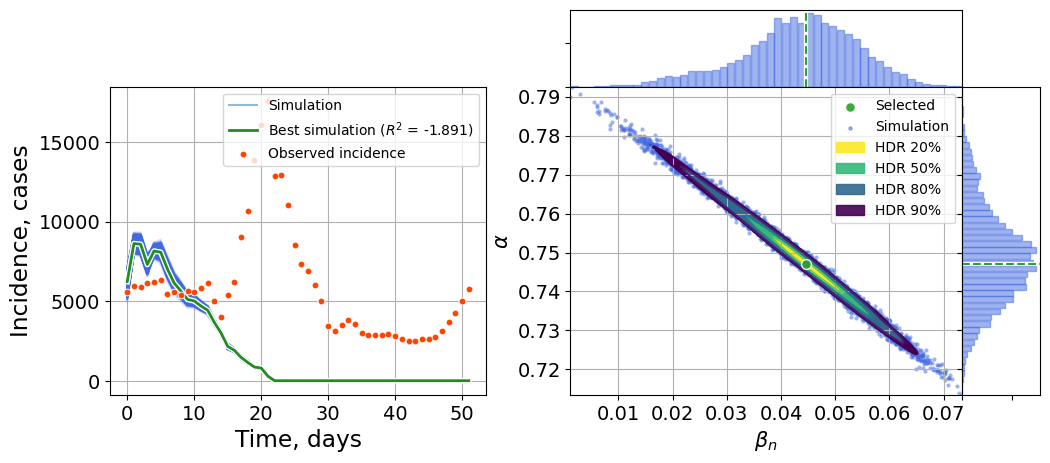

In [204]:
idatat = az.from_netcdf(f"surr_on_real/ba_surr_{draws}_{chains}_eps{epsilon}_g{gamma[0]}_d{delta[0]}.nc")
network_params=[[False],[0],[0],[gamma],[delta],[n_nodes], top, koeff]
plot_funcs.plot_calib(np.array(new_observed), idatat, 
               true_tau, true_alpha, 
               network_params, pred=False, with_observed=False)